Gradient descent is a method for unconstrained mathematical optimization. It is a first-order iterative algorithm for minimizing a differentiable multivariate function.

The idea is to take repeated steps in the opposite direction of the gradient (or approximate gradient) of the function at the current point, because this is the direction of steepest descent. Conversely, stepping in the direction of the gradient will lead to a trajectory that maximizes that function; the procedure is then known as gradient ascent. It is particularly useful in machine learning for minimizing the cost or loss function.[1] Gradient descent should not be confused with local search algorithms, although both are iterative methods for optimization.

b(new) = b(old)-learning_rate*slope(at b)


In [28]:
# implementation of gradient descent 
from sklearn.datasets import make_regression
import numpy as np

In [29]:
X,y = make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

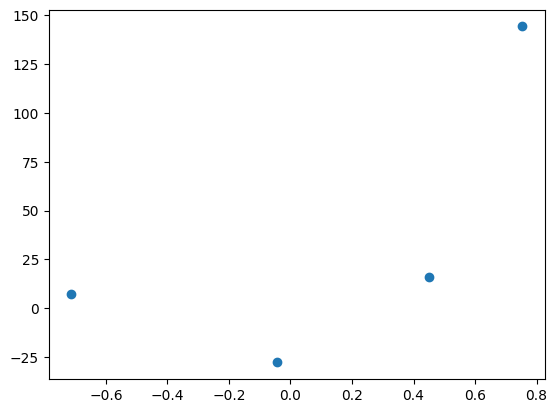

In [30]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [31]:
# first lets apply OLS(Ordinary Least Squares) to find the best fit line
from sklearn.linear_model import LinearRegression

In [32]:
lr = LinearRegression()
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
lr.coef_, lr.intercept_ # slope and intercept

(array([78.35063668]), 26.15963284313262)

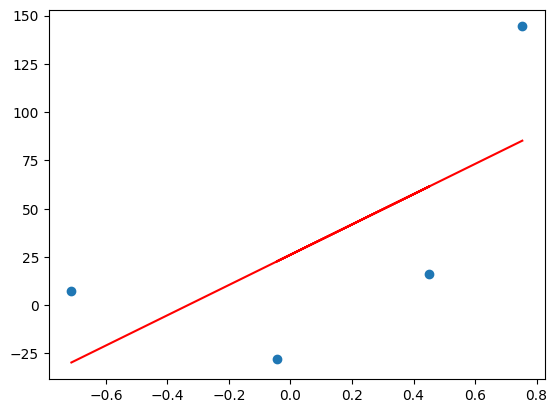

In [34]:
plt.scatter(X,y)
plt.plot(X, lr.predict(X), color='red')

In [35]:
# lets apply gradient descent assuming slope is constant, m=78.35
# and starting intercept b=0
y_pred = ((78.35*X) + 0).reshape(4)

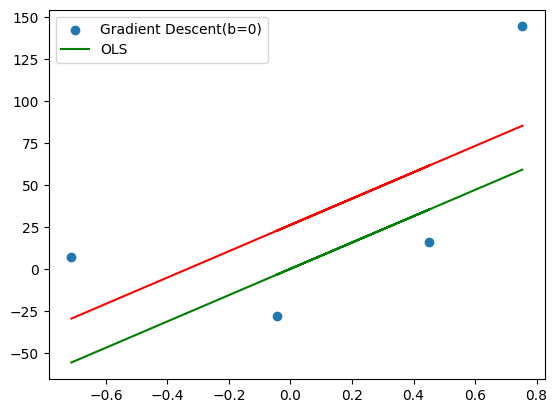

In [36]:
plt.scatter(X,y)
plt.plot(X, y_pred, color='green',label='b=0')
plt.plot(X, lr.predict(X), color='red')
plt.legend(['Gradient Descent(b=0)','OLS'])
plt.show()

In [37]:
m = 78.35
b = 0

loss_slope = -2 * np.sum(y-m*X.ravel()-b)
loss_slope

-209.27763408209216

In [38]:
# lets take learning rate = 0.1
ss = 0.1
step_size = loss_slope*ss
step_size

-20.927763408209216

In [39]:
# calculating new b

b = b - step_size
b

20.927763408209216

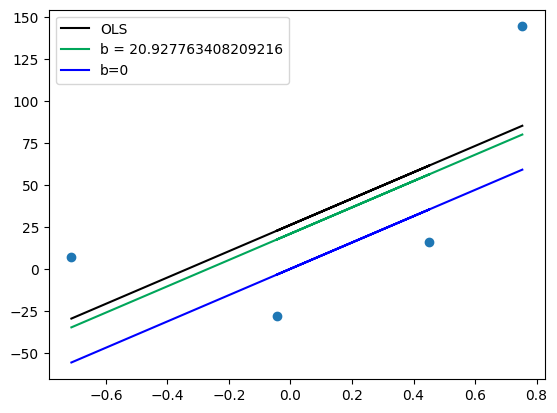

In [41]:
y_pred1 = ((78.35*X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,lr.predict(X), color='black',label='OLS')
plt.plot(X, y_pred1, color='#00a65a',label='b = {}'.format(b))
plt.plot(X, y_pred, color='blue',label='b=0')
plt.legend()
plt.show()



In [42]:
# iteration 2
loss_slope = -2 * np.sum(y-m*X.ravel()-b)
loss_slope

-41.85552681641843

In [43]:
step_size = loss_slope*ss
step_size

-4.185552681641844

In [44]:
b = b - step_size
b

25.11331608985106

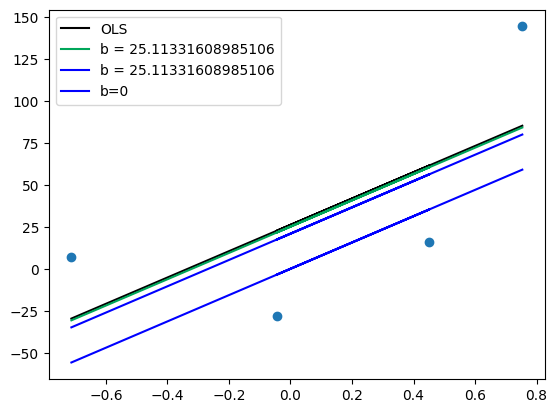

In [46]:
y_pred2 = ((78.35*X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,lr.predict(X), color='black',label='OLS')
plt.plot(X, y_pred2, color='#00a65a',label='b = {}'.format(b))
plt.plot(X, y_pred1, color='blue',label='b = {}'.format(b))
plt.plot(X, y_pred, color='blue',label='b=0')
plt.legend()
plt.show()



In [47]:
# iteration 3
loss_slope = -2 * np.sum(y-m*X.ravel()-b)
loss_slope

-8.371105363283675

In [48]:
step_size = loss_slope*ss
step_size

-0.8371105363283675

In [49]:
b = b - step_size
b

25.95042662617943

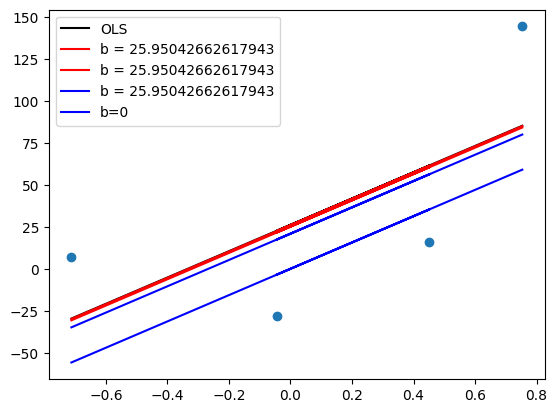

In [51]:
y_pred3 = ((78.35*X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,lr.predict(X), color='black',label='OLS')
plt.plot(X, y_pred3, color='red',label='b = {}'.format(b))
plt.plot(X, y_pred2, color='red',label='b = {}'.format(b))
plt.plot(X, y_pred1, color='blue',label='b = {}'.format(b))
plt.plot(X, y_pred, color='blue',label='b=0')
plt.legend()
plt.show()



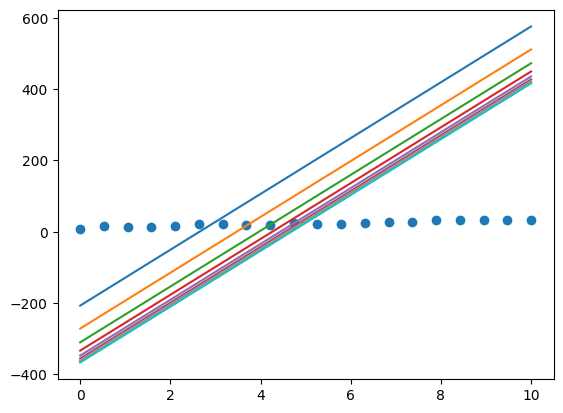

In [54]:
# instead of seperate iterations we can put all in a loop

b = -100
m = 78.35
ss = 0.01 # learning rate

epochs = 10

for i in range(epochs):
    loss_slope = -2 * np.sum(y-m*X.ravel()-b)
    b = b - (loss_slope*ss)
    
    y_pred = ((m*X) + b)
    
    plt.plot(X,y_pred)
    
plt.scatter(X,y)
    



# Making a class for implementing Gradient Descent

In [75]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score


In [76]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)

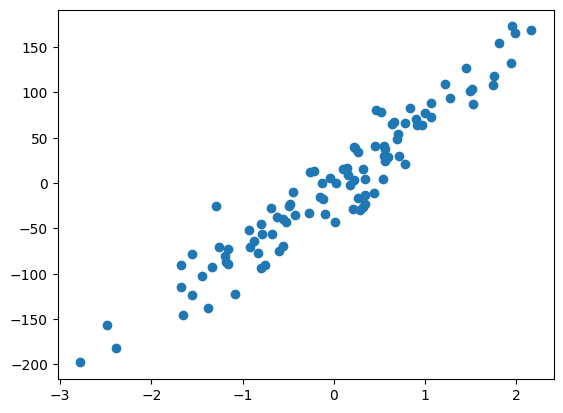

In [77]:
plt.scatter(X,y)

In [78]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [80]:
np.mean(cross_val_score(reg,X,y,scoring='r2',cv=10))

0.8804394992226626

In [59]:
reg.coef_, reg.intercept_

(array([37.82771807]), 0.8139131118919156)

In [60]:
m = 37.82


In [87]:
class GDregressor:
    def __init__ (self,learning_rate,epochs):
        self.m = 100 # initial slope
        self.b = -120     #  initial intercept
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X,y):
        # calculate b using gradient descent
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y-self.m*X.ravel()-self.b)
            loss_slope_m = -2 * np.sum((y-self.m*X.ravel()-self.b)*X.ravel())
            self.b = self.b - (loss_slope_b*self.lr)
            self.m = self.m - (loss_slope_m*self.lr)
            
        print("Final b:",self.b, "Final m:",self.m) 

In [106]:
gd = GDregressor(0.001,500000)


In [107]:
gd.fit(X,y)

Final b: -1.9605578424001253 Final m: 71.92638338710995
